# Project Setup

This is a personal project by Bryan Beus -- https://bluesanta.io -- to explore effective and ineffective Kickstarter campaigns, with regards to data analytics and machine learning.

In this particular notebook, we'll import our visualized dataset, prepare the data for modeling, and then create predictive models.

## Library Imports

In [1]:
# Common DataFrame Tools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import matplotlib as mpl
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
#

# Python Libraries
from datetime import datetime
import json
from wordcloud import WordCloud, STOPWORDS
import time

In [2]:
# The following imports are libraries that we can general use for these types of projects
# Not all libraries are used at this time

import statsmodels.api as sm
from statsmodels.graphics.api import abline_plot
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import linear_model, preprocessing
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, r2_score
 
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

# Logistic Regression set
from sklearn.preprocessing import OneHotEncoder as OHE
import sklearn.model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
#
# GridSearchCV
from sklearn import svm
from sklearn.model_selection import GridSearchCV
#
print("Loaded Libraries")

Loaded Libraries


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
#
plt.rcParams['figure.figsize'] = (3, 3)
plt.style.use('seaborn-v0_8-pastel')
plt.rcParams['figure.dpi'] = 150      
#
c0 = sns.color_palette()[0]
c1 = sns.color_palette()[1]
c2 = sns.color_palette()[2]
#
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
cm = plt.cm.RdBu
cm_bright = ListedColormap(['#FF0000', '#0000FF'])
#

# This function is copied from a LogisticRegression exercise in Springboard Academy
# This function creates an aesthetic plot of two features of a dataframe that is intended for a binary output classification
def points_plot(ax, Xtr, Xte, ytr, yte, 
                clf, 
                mesh = True, colorscale = cmap_light, cdiscrete = cmap_bold, 
                alpha = 0.01, psize = 10, 
                zfunc = False, predicted = False):
#
# note: this function only works for X.shape = (:, 2)
# it is intended to illustrate the classifier boundary
#
# get the column names if they exist to apply
# to the meshed data generated below
#
    try:
        feature_names = Xtr.columns
    except:
        feature_names = None
#        
    Xtrain = np.array(Xtr)
    Xtest = np.array(Xte)
#
    h = 0.02
#
# create a uniform grid spanning the range of the X values
# note that y here is NOT the target, it is the 2nd
# dimension of the desired plot
#
    X = np.concatenate((Xtrain, Xtest))
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
#
# predict the target value at each point in the grid
#
# this method uses the probabilities from the classifier
# and applies a function to determine the class
#
    if zfunc:
        mesh_data = np.c_[xx.ravel(), yy.ravel()]
        if feature_names is not None:
            mesh_data = pd.DataFrame(mesh_data, 
                         columns = feature_names)
        p0 = clf.predict_proba(mesh_data)[:, 0]
        p1 = clf.predict_proba(mesh_data)[:, 1]
        Z = zfunc(p0, p1)
#
# this method uses the classifier to predict the classes directly
#
    else:
        mesh_data = np.c_[xx.ravel(), yy.ravel()]
        if feature_names is not None:
            mesh_data = pd.DataFrame(mesh_data, 
                                     columns = feature_names)
        Z = clf.predict(mesh_data)
    ZZ = Z.reshape(xx.shape)
#
# plt.pcolormesh() creates a shaded result over the grid
#
    if mesh:
        plt.pcolormesh(xx, yy, ZZ, 
                       cmap = cmap_light, 
                       alpha = alpha, 
                       axes = ax, 
                       shading = 'auto')
#
# add the points to the plot
# these can be the original target values
# or the predicted values
#
    if predicted:
        showtr = clf.predict(Xtr)
        showte = clf.predict(Xte)
    else:
        showtr = ytr
        showte = yte
#
# set xcale logarithmic
#
    ax.set_xscale('log')
    ax.set_yscale('log')
#
# plot training points
#
    ax.scatter(Xtrain[:, 0], Xtrain[:, 1], 
               c = showtr - 1, 
               cmap = cmap_bold, 
               s = psize, 
               alpha = alpha, 
               edgecolor = "k")
#    
# plot testing points
#
    ax.scatter(Xtest[:, 0], Xtest[:, 1],
               c = showte - 1, 
               cmap = cmap_bold, 
               s = psize + 10,
               alpha = alpha, 
               marker = "s")
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
#
    return ax, xx, yy

## DataFrame Import

In [4]:
df = pd.read_parquet('../../metadata/02-ksr-metadata.parquet', engine='pyarrow')

In [5]:
df.head()

,id,name,blurb,goal,pledged,state,slug,country,country_displayable_name,currency,currency_symbol,currency_trailing_code,deadline,state_changed_at,created_at,launched_at,staff_pick,backers_count,static_usd_rate,usd_pledged,converted_pledged_amount,fx_rate,usd_exchange_rate,current_currency,usd_type,percent_funded,creator.id,creator.name,creator.has_admin_message_badge,creator.partner_badge,creator.ppo_has_action,creator.backing_action_count,location.id,location.name,location.short_name,location.displayable_name,location.localized_name,location.country,location.state,location.type,location.expanded_country,category.id,category.name,category.analytics_name,category.slug,category.position,category.parent_id,category.parent_name,category.color,urls.web.project,creator.is_ksr_admin,relevant_category
0,1703332404,Massage By Donation... Seriously!,Physical wellness is not a luxury; it is a necessity!,53170.0,52.0,failed,massage-by-donation-seriously,US,the United States,USD,$,True,2025-03-31 09:32:41,2025-03-31 09:32:45,2025-01-10 11:45:15,2025-01-30 09:32:41,False,3,1.000000,52.0,52.0,1.000000,1.000000,USD,domestic,0.097800,85356126,Pressure Massage,False,False,False,0,2520740.0,Williams,"Williams, AZ","Williams, AZ",Williams,US,AZ,Town,United States,395,Social Practice,Social Practice,art/social practice,11,1.0,Art,16760235,https://www.kickstarter.com/projects/pressuremassage/massage-by-donation-seriously,False,1.0
1,1704943227,eifel-abenteuer.de - Nachhaltige Outdoorangebote erschaffen,Aufbau eines erlebnispädagogischen Outdooraktionen und Spieleanbieters. Ich bau in 4 Monaten eine Gelände zum Veranstaltungsort um.,10000.0,0.0,failed,eifel-abenteuerde-nachhaltige-outdoorangebote-erschaffen,DE,Germany,EUR,€,False,2025-03-22 02:29:39,2025-03-22 02:29:40,2025-01-07 02:22:12,2025-01-21 02:29:39,False,0,1.030272,0.0,0.0,1.138244,1.087666,USD,domestic,0.000000,2075243650,Tobias Kaiser,False,False,False,0,12628318.0,Gemeinde Polch,"Gemeinde Polch, Germany","Gemeinde Polch, Germany",Gemeinde Polch,DE,Rhineland-Palatinate,LocalAdmin,Germany,271,Live Games,Live Games,games/live games,2,12.0,Games,51627,https://www.kickstarter.com/projects/eifel-abenteuer/eifel-abenteuerde-nachhaltige-outdoorangebote-erschaffen,False,12.0
2,150178599,"Graphic Novel ""Pachacuti""","Graphic Novel cruda e intensa, narrata in uno stile sperimentale, che esplora l'uomo contemporaneo afflitto dal suo sé e da falsi idoli",2500.0,34.0,failed,graphic-novel-pachacuti,IT,Italy,EUR,€,False,2025-03-08 07:28:11,2025-03-08 07:58:29,2025-01-03 03:52:01,2025-01-07 07:28:11,False,2,1.031525,35.07186632,36.0,1.138244,1.083199,USD,domestic,1.360000,2067729342,tiziano,False,False,False,0,717162.0,Lecce,"Lecce, Italy","Lecce, Italy",Lecce,IT,Puglia,Town,Italy,252,Graphic Novels,Graphic Novels,comics/graphic novels,4,3.0,Comics,16776056,https://www.kickstarter.com/projects/pacachuti/graphic-novel-pachacuti,False,3.0
3,699875365,MadeInTuskegee: Pop-Up Shops and Open-Air Courtyard Project,Help Fund Our Renovation: Transforming a Historic Building into a Thriving Space for Local Businesses,150537.0,210.0,failed,madeintuskegee-pop-up-shops-and-open-air-courtyard-project,US,the United States,USD,$,True,2025-02-16 06:59:23,2025-02-16 06:59:24,2023-06-11 16:44:25,2024-12-18 06:59:23,False,3,1.000000,210.0,210.0,1.000000,1.000000,USD,domestic,0.139501,439845884,J. Taylor,False,False,False,0,2508954.0,Tuskegee,"Tuskegee, AL","Tuskegee, AL",Tuskegee,US,AL,Town,United States,395,Social Practice,Social Practice,art/social practice,11,1.0,Art,16760235,https://www.kickstarter.com/projects/madeintuskegee/madeintuskegee-pop-up-shops-and-open-air-courtyard-project,False,1.0
4,739499553,Goddesses in Everywoman,A guided multimedia self-discovery journey,3900.0,0.0,failed,goddesses-in-everywoman,US,the United States,USD,$,True,2025-01-15 13:02:26,2025-01-15 13:02:28,2024-12-16 10:43:02,2024-12-16 13:02:26,False,0,1.000000,0.0,0.0,1.000000,1.000000,USD,domestic,0.000000,1777086509,Lola Carneiro,False,F

# Preprocessing

## Dropping Unnecessary Columns

Several columns are useful for identification and other purposes, but are not appropriate for modeling.

We create a dataframe with a reduced number of columns, keeping only those that are necessary for the model.

Our target for predictive modeling is the `state` column, keeping only `successful` and `failed` values.

We drop all of the `pledged` related columns, because we are concerned about those factors that are known and/or under our control at the outset. The `pledged` related columns do not fit under that premise.

In [6]:
# Keep the 'id' column as the index so that we can use it for identification purposes 
df = df.set_index('id')

In [7]:
df.columns

Index(['name', 'blurb', 'goal', 'pledged', 'state', 'slug', 'country',
       'country_displayable_name', 'currency', 'currency_symbol',
       'currency_trailing_code', 'deadline', 'state_changed_at', 'created_at',
       'launched_at', 'staff_pick', 'backers_count', 'static_usd_rate',
       'usd_pledged', 'converted_pledged_amount', 'fx_rate',
       'usd_exchange_rate', 'current_currency', 'usd_type', 'percent_funded',
       'creator.id', 'creator.name', 'creator.has_admin_message_badge',
       'creator.partner_badge', 'creator.ppo_has_action',
       'creator.backing_action_count', 'location.id', 'location.name',
       'location.short_name', 'location.displayable_name',
       'location.localized_name', 'location.country', 'location.state',
       'location.type', 'location.expanded_country', 'category.id',
       'category.name', 'category.analytics_name', 'category.slug',
       'category.position', 'category.parent_id', 'category.parent_name',
       'category.color', 'urls.

In [8]:
# If not done previously, create a converted_goal_amount column
df['converted_goal_amount'] = df['goal'] * df['static_usd_rate']

Drop all the columns that are not an appropriate fit for our model.

In [9]:
dfm = df.drop(columns=[
    'name',
    'blurb',
    'slug',
    'goal',
    'pledged',
    'country_displayable_name',
    'currency_symbol',
    'currency_trailing_code',
    'deadline',
    'state_changed_at',
    'created_at',
    'launched_at',
    'static_usd_rate',
    'usd_pledged',
    'converted_pledged_amount', 
    'fx_rate',
    'usd_exchange_rate',
    'current_currency',
    'usd_type',
    'percent_funded',
    'creator.id',
    'creator.name',
    'creator.ppo_has_action',
    'location.id',
    'location.name',
    'location.short_name',
    'location.displayable_name',
    'location.localized_name',
    'location.country',
    'location.state',
    'location.type',
    'location.expanded_country',
    'category.id',
    'category.name',
    'category.analytics_name',
    'category.slug',
    'category.position',
    'category.parent_name',
    'category.parent_id',
    'category.color',
    'urls.web.project',
    'creator.is_ksr_admin'
])

In [10]:
dfm.head()

,state,country,currency,staff_pick,backers_count,creator.has_admin_message_badge,creator.partner_badge,creator.backing_action_count,relevant_category,converted_goal_amount
id,,,,,,,,,,
1703332404,failed,US,USD,False,3,False,False,0,1.0,53170.0000
1704943227,failed,DE,EUR,False,0,False,False,0,12.0,10302.7250
150178599,failed,IT,EUR,False,2,False,False,0,3.0,2578.8137
699875365,failed,US,USD,False,3,False,False,0,1.0,150537.0000
739499553,failed,US,USD,False,0,False,False,0,1.0,3900.0000


In [11]:
# Drop any 'cancelled' or other outcomes as we only want to focus on successful or failed projects
dfm = dfm[(dfm['state'] == 'successful') | (dfm['state'] == 'failed')]

Let's check and see if the admin/partner badge columns have any value. 

In [12]:
dfm.sort_values(by='creator.has_admin_message_badge', ascending=False)

,state,country,currency,staff_pick,backers_count,creator.has_admin_message_badge,creator.partner_badge,creator.backing_action_count,relevant_category,converted_goal_amount
id,,,,,,,,,,
1703332404,failed,US,USD,False,3,False,False,0,1.0,53170.000000
1476755569,successful,GB,GBP,True,264,False,False,0,18.0,251.880604
1020709194,successful,US,USD,False,144,False,False,0,18.0,7500.000000
21274643,successful,US,USD,True,180,False,False,0,18.0,10000.000000
2079810328,successful,US,USD,False,52,False,False,0,18.0,2500.000000
...,...,...,...,...,...,...,...,...,...,...
590059957,successful,IE,EUR,False,15,False,False,0,14.0,5247.773650
1814098243,successful,IT,EUR,False,66,False,False,0,14.0,1882.242720
799085709,successful,GB,GBP,False,244,False,False,0,14.0,11338.068420


In [13]:
dfm['creator.has_admin_message_badge'].value_counts()

creator.has_admin_message_badge
False    86514
Name: count, dtype: int64

There are  no admin message badges at this point. This column can go.

In [14]:
dfm['creator.partner_badge'].value_counts()

creator.partner_badge
False    86496
True        18
Name: count, dtype: int64

There is some variety here. However, do partners automatically succeed?

In [15]:
dfm[(dfm['creator.partner_badge'] == True) & (dfm['state'] == 'failed')].head()

,state,country,currency,staff_pick,backers_count,creator.has_admin_message_badge,creator.partner_badge,creator.backing_action_count,relevant_category,converted_goal_amount
id,,,,,,,,,,


This appears to be the case. Partners essentially always win.

There's really no need to include this aspect in our model. If you are a Kickstarter partner, then according to this dataset, you will likely succeed.

Let's check and see if there are instances where a project is a staff_pick but the project failed.

In [16]:
dfm[(dfm['staff_pick'] == True) & (dfm['state'] == 'failed')].shape

(939, 10)

In [17]:
dfm[(dfm['staff_pick'] == True) & (dfm['state'] == 'successful')].shape

(13222, 10)

There are `939` instances of failures out of almost `15000`, so this is useful information.

We convert the `state` and `staff_pick` columns into binary `0` and `1` values for regression purposes.

In [18]:
# Convert string values into binary values for the `state` column
def convert_state_binary(x):
    if x == 'successful':
        return 1
    else:
        return 0
dfm['state'] = dfm['state'].apply(convert_state_binary)

In [19]:
class_counts = dfm['state'].value_counts()
class_counts

state
1    55856
0    30658
Name: count, dtype: int64

In [20]:
# Convert booleon values into binary values for the `staff_pick` column
def convert_staff_binary(x):
    if x == True:
        return 1
    else:
        return 0
dfm['staff_pick'] = dfm['staff_pick'].apply(convert_staff_binary)

In [21]:
dfm = dfm.drop(columns=['creator.has_admin_message_badge', 'creator.partner_badge'])

In [22]:
dfm.head()

,state,country,currency,staff_pick,backers_count,creator.backing_action_count,relevant_category,converted_goal_amount
id,,,,,,,,
1703332404,0,US,USD,0,3,0,1.0,53170.0000
1704943227,0,DE,EUR,0,0,0,12.0,10302.7250
150178599,0,IT,EUR,0,2,0,3.0,2578.8137
699875365,0,US,USD,0,3,0,1.0,150537.0000
739499553,0,US,USD,0,0,0,1.0,3900.0000


In [23]:
dfm.shape

(86514, 8)

At this point, we have our columns narrowed down to the simplest features.

We are prepared to create a model that attempts to predict a binary outcome: 'success' or 'failure'.

We can also later come back, add back in the `converted_pledged_amount` column, drop all the `failed` rows, and with the `successful` rows create a linear regression model that predicts the variable level of success given a similar set of independent features.

## Creating Dummy Variables

We create our dummy variables for our categorical columns.

In [24]:
df_d = pd.get_dummies(dfm, columns=['country', 'currency', 'relevant_category'], prefix='c')

In [25]:
df_d.columns = df_d.columns.astype(str)

In [26]:
df_d.head()

,state,staff_pick,backers_count,creator.backing_action_count,converted_goal_amount,c_AT,c_AU,c_BE,c_CA,c_CH,c_DE,c_DK,c_ES,c_FR,c_GB,c_GR,c_HK,c_IE,c_IT,c_JP,c_LU,c_MX,c_NL,c_NO,c_NZ,c_PL,c_SE,c_SG,c_SI,c_US,c_AUD,c_CAD,c_CHF,c_DKK,c_EUR,c_GBP,c_HKD,c_JPY,c_MXN,c_NOK,c_NZD,c_PLN,c_SEK,c_SGD,c_USD,c_1.0,c_3.0,c_6.0,c_7.0,c_9.0,c_10.0,c_11.0,c_12.0,c_13.0,c_14.0,c_15.0,c_16.0,c_17.0,c_18.0,c_26.0
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1703332404,0,0,3,0,53170.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1704943227,0,0,0,0,10302.7250,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
150178599,0,0,2,0,2578.8137,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
699875365,0,0,3,0,150537.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
739499553,0,0,0,0,3900.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Calculating Target Feature Balance

In [27]:
class_percentages = pd.Series([(x / df_d.shape[0]) * 100.00 for x in class_counts])
class_percentages

0    64.562961
1    35.437039
dtype: float64

We use the percentages as labels and plot the distribution.

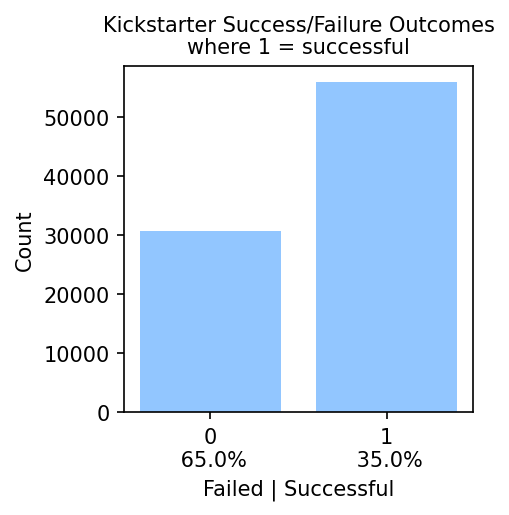

In [28]:
fig, ax = plt.subplots()
ax.bar(class_counts.index, class_counts)
ax.set_xticks([0, 1])
ax.set_xticklabels(class_percentages.index.astype(str) + '\n' + ' ' +
                   class_percentages.round(0).astype(str) + '%')
ax.set_ylabel('Count')
ax.set_xlabel('Failed | Successful')
ax.set_title('Kickstarter Success/Failure Outcomes\nwhere 1 = successful',
              fontsize = 10)
plt.show()

## Train Test Split

### Building a Model with Only Two Features

By way of exploration, let's build a model using only two features. We'll use `converted_goal_amount` and `backers_count` as our two features. 

These two features are useful, because an experienced businessman can create a reasonably useful guess at how many people will support their campaign based on customer activity, and the businessman can arbitrarily determine their stated goal. 

We divide the data into training and test sets.

In [29]:
X = pd.DataFrame(df_d[['converted_goal_amount', 'backers_count']])
y = pd.DataFrame(df_d['state']).values.ravel()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                y,
                                                train_size = 0.75,
                                                random_state = 42)

# Predictive Modeling

## Logistic Regression

### Two Features

Create a classifier object for our LogisticRegression model.

In [31]:
classifier = LogisticRegression(solver = 'liblinear', max_iter = 500, C = 1000)

In [32]:
classifier.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1000
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,500
,multi_class,'deprecated'


Calculate the accuracy.

In [33]:
print(f'Accuracy on training data: {accuracy_score(classifier.predict(X_train), y_train):.2f}')

Accuracy on training data: 0.92


A preliminary accuracy score of `0.92` is a respectable result. This implies that, if we have a strong idea of the number of the people who are in a financially supportive relationship, we can test various goal amounts to determine the limits of a successful outcome.

Let's plot our features.

/tmp/ipykernel_940943/471954867.py:119: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(yy.min(), yy.max())


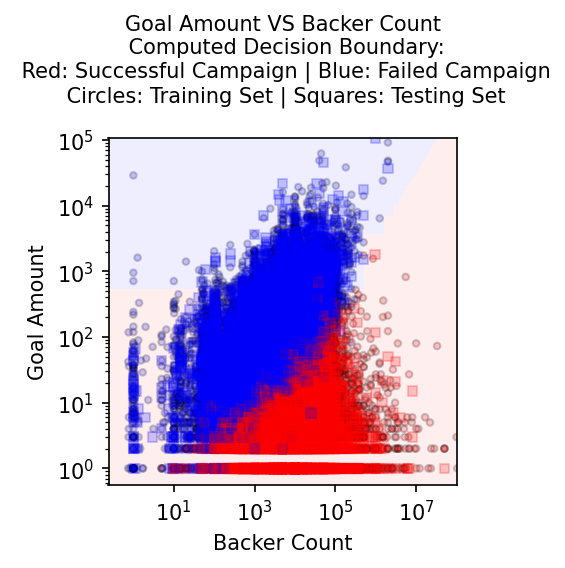

In [34]:
plt.figure()
ax = plt.gca()
ax.set_ylabel('Goal Amount')
ax.set_xlabel('Backer Count')
ax.set_title('Goal Amount VS Backer Count\n ' +
             'Computed Decision Boundary:' +
             '\n Red: Successful Campaign | Blue: Failed Campaign' +
             '\n Circles: Training Set | Squares: Testing Set\n',
            fontsize = 10)
_ = points_plot(ax, X_train, X_test, y_train, y_test, classifier, alpha = 0.2)

As we can see here, campaigns (in red) that had large amounts of backers and lower or at least more realistic goals were more likely to succeed. 

Campaigns that set lofty goals (marked in blue) were far less likely to succeed, even if they had significant numbers of backers.

Let's use the classification reporting system.

In [35]:
print("Classification Report for Training Data")
print(classification_report(y_train, classifier.predict(X_train)))

Classification Report for Training Data
              precision    recall  f1-score   support

           0       0.95      0.81      0.88     22925
           1       0.91      0.98      0.94     41960

    accuracy                           0.92     64885
   macro avg       0.93      0.90      0.91     64885
weighted avg       0.92      0.92      0.92     64885



In [36]:
print("Classification Report for Test Data")
print(classification_report(y_test, classifier.predict(X_test)))

Classification Report for Test Data
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      7733
           1       0.91      0.98      0.94     13896

    accuracy                           0.92     21629
   macro avg       0.93      0.90      0.91     21629
weighted avg       0.92      0.92      0.92     21629



The precision, recall, and f1-score are all over `0.8`, and even become as high as `0.95`. This suggest that these two indicators are key features for predicting campaign outcome.

The accuracy (the number of correct predictions out of all attempts) is `0.91 - 0.95`.

The recall (the model's ability to find positive cases out of of all of the positive cases in the dataset) is `0.81 - 0.98`. 

The f1-score (the harmonic mean between accuracy and recall) is `0.88 - 0.94`.

### Build a Model Using All Features

We build a model using all available features, and check to see if this information improves the overall model effectiveness.

In [37]:
X = pd.DataFrame(df_d.drop(columns=['state']))
y = pd.DataFrame(df_d['state']).values.ravel()

In [38]:
list(X.columns)

['staff_pick',
 'backers_count',
 'creator.backing_action_count',
 'converted_goal_amount',
 'c_AT',
 'c_AU',
 'c_BE',
 'c_CA',
 'c_CH',
 'c_DE',
 'c_DK',
 'c_ES',
 'c_FR',
 'c_GB',
 'c_GR',
 'c_HK',
 'c_IE',
 'c_IT',
 'c_JP',
 'c_LU',
 'c_MX',
 'c_NL',
 'c_NO',
 'c_NZ',
 'c_PL',
 'c_SE',
 'c_SG',
 'c_SI',
 'c_US',
 'c_AUD',
 'c_CAD',
 'c_CHF',
 'c_DKK',
 'c_EUR',
 'c_GBP',
 'c_HKD',
 'c_JPY',
 'c_MXN',
 'c_NOK',
 'c_NZD',
 'c_PLN',
 'c_SEK',
 'c_SGD',
 'c_USD',
 'c_1.0',
 'c_3.0',
 'c_6.0',
 'c_7.0',
 'c_9.0',
 'c_10.0',
 'c_11.0',
 'c_12.0',
 'c_13.0',
 'c_14.0',
 'c_15.0',
 'c_16.0',
 'c_17.0',
 'c_18.0',
 'c_26.0']

We create our train and test sets. Note that we use the `stratify` parameter to preserve the overall balance of `success/failure` values.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.75, stratify = y, random_state = 42)

In [40]:
# Create our classification object
clf = LogisticRegression(solver = 'newton-cg', max_iter = 500)

In [41]:
clf.fit(X_train, y_train) 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'newton-cg'
,max_iter,500
,multi_class,'deprecated'


In [42]:
# Test the predictions
y_predict_test = clf.predict(X_test)
y_predict_training = clf.predict(X_train)

In [43]:
print("[Test] Accuracy score (y_predict_test, y_test):",
      f'{accuracy_score(y_predict_test, y_test):.2f}')

[Test] Accuracy score (y_predict_test, y_test): 0.93


Compute the metric on the training data

In [44]:
print("[Training] Accuracy score: (y_train, y_predict_training)", 
      f'{accuracy_score(y_train, y_predict_training):.2f}')

[Training] Accuracy score: (y_train, y_predict_training) 0.93


### LogisticRegression Model Performance

With an train accuracy score of `0.93` and an essentially identical test accuracy score of `0.93`, we have reasonable confidence that the model will generalize well.

### Confusion Matrix

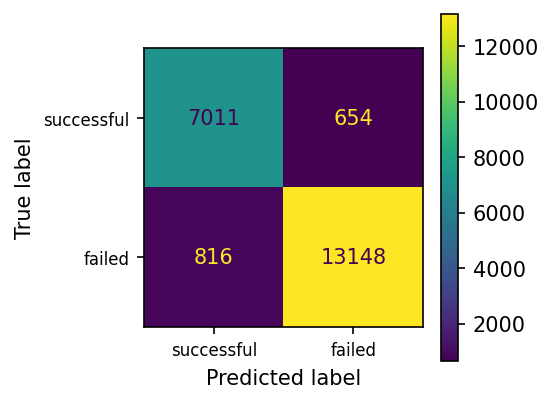

In [45]:
cm = confusion_matrix(y_test, y_predict_test, labels = clf.classes_)
_, ax = plt.subplots()
display_cm = ConfusionMatrixDisplay(confusion_matrix = cm, 
                                    display_labels = ['successful', 'failed'])
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels = ['successful', 'failed'], fontsize = 8)
ax.set_yticklabels(labels = ['successful', 'failed'], fontsize = 8)
display_cm.plot(ax = ax)

Our confusion matrix shows that `7011` successful campaigns were correctly predicted, while `654` successful campaigns were misclassified as failures.

On the bottom row, we have `13148` correctly identified failed campaigns and `816` failed campaigns misclassified as successes.

### Logistic Regression Summary

Overall, with accuracy and recall scores between `0.8` and `0.94`, we have a viable model for predicting Kickstarter campaign success.

A business could use this data and model, along with their available data about active customers and gathered survey responses, to ascertain a reasonable level of support they could expect for a Kickstarter campaign.  

## Decision Tree

We explore another type of machine learning model, Decision Trees, to see if we can generate similar results. 

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn import tree, metrics

In [47]:
RFModel = RandomForestClassifier(max_depth=3, random_state=42)

We can continue to use our stratified train and test sets.

In [48]:
RFModel.fit(X_train, y_train)

y_pred = RFModel.predict(X_test)

y_pred = pd.Series(y_pred)

In [49]:
print("Radom Forest Classifier - max depth 3")
print("Accuracy:", metrics.accuracy_score(y_test,y_pred))
print("Balanced accuracy:", metrics.balanced_accuracy_score(y_test,y_pred))
print('Precision score' , metrics.precision_score(y_test,y_pred, pos_label = 1))
print('Recall score' , metrics.recall_score(y_test,y_pred, pos_label = 0))

Radom Forest Classifier - max depth 3
Accuracy: 0.8960192334365897
Balanced accuracy: 0.8712435742416946
Precision score 0.8906823184152605
Recall score 0.7861709067188519


The accuracy here is, `0.896`, which is less than LogisticRegression - `0.93`. The other metrics are also lower.

While this RandomForest model does appear to be useful, it is not as competitive.

## KMeans Clustering

Finally, we create a KMeans Cluster model so that we can explore a few similarities between projects.

In [50]:
from sklearn.cluster import KMeans

We'll start by checking the approximate maximum number of clusters, which is the number of rows in the dataset, and then we'll reduce the number of clusters until we find a suitable resting point. 

In [51]:
list(df_d.shape)

[86514, 60]

In [52]:
n_clusters = 86000
model = KMeans(n_clusters=n_clusters)

In [53]:
# Comment this line in or out depending on whether or not you want it to run. 
# I have created a hard-coded copy of the results below, so that there's no need to rerun it, given the same parameters.
# At 86000 clusters, this will take awhile.
# model.fit(df_d)

Running this (if uncommented) gives us a warning message:

```
ConvergenceWarning: Number of distinct clusters (68932) found smaller than n_clusters (86000). Possibly due to duplicate points in X.
```

This suggests that the maximum number of distinct clusters we can find is `68932`.

In [54]:
# Uncomment if the model runs.
# print(model.inertia_)

The model inertia (when run) is `2.8415758751096617e-19`, or almost zero.

This means that all of the data points are essentially touching the center of the clusters.

We're going to use the elbow method to discover an ideal number of clusters.

Let's create a numpy matrix of our number of clusters and inertia results. 

In [55]:
results = np.array([])

Let's try reducing the number of clusters. We'll check along the way to see how the inertia runs.

In [56]:
possible_k = list(range(500, 68000, 500))

In [57]:
run = False
if run:
    for i in possible_k:
        start_time = time.perf_counter()
        print(f"Starting cluster of value: {i}")
        scaler = StandardScaler()
        model = KMeans(n_clusters=i)
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('kmeans', KMeans(n_clusters=i, random_state=42))
        ])
    
        pipeline.fit(df_d)
        fitted_kmeans = pipeline.named_steps["kmeans"]
        inertia = fitted_kmeans.inertia_
        results = np.append(results, [i, inertia], axis=0)
        end_time = time.perf_counter()
        elapsed_time = end_time - start_time
        print(f"Elapsed time: {elapsed_time:.4f} seconds")

In [58]:
res = pd.DataFrame()
if run:
    evens = results[::2]
    odds = results[1::2]
    res = pd.DataFrame(
        {'clusters': evens,
        'inertia': odds}
    )

In [59]:
if run:
    print(res.to_dict(orient='list'))

In [60]:
if (run == False):
    res = pd.DataFrame(
        {'clusters': [500.0, 1000.0, 1500.0, 2000.0, 2500.0, 3000.0, 3500.0, 4000.0, 4500.0, 5000.0, 5500.0, 6000.0, 6500.0, 7000.0, 7500.0, 8000.0, 8500.0, 9000.0, 9500.0, 10000.0, 10500.0, 11000.0, 11500.0, 12000.0, 12500.0, 13000.0, 13500.0, 14000.0, 14500.0, 15000.0, 15500.0, 16000.0, 16500.0, 17000.0, 17500.0, 18000.0, 18500.0, 19000.0, 19500.0, 20000.0, 20500.0, 21000.0, 21500.0, 22000.0, 22500.0, 23000.0, 23500.0, 24000.0],
         'inertia': [41554.838803890954, 8344.445969832363, 1979.7188836122232, 476.22372115093026, 186.010151574824, 96.56316007151884, 57.85257441589856, 38.739168631029095, 27.311156656854312, 20.16512975870279, 15.46425268464746, 12.141064172367951, 9.762452588820311, 8.000221828945875, 6.618951446214228, 5.59022602744614, 4.717237456907759, 4.028024666745704, 3.4753868487381956, 3.0285562106930852, 2.6422563704860553, 2.3237695941457472, 2.0504604525487418, 1.8274861497515584, 1.6262273382981864, 1.453553486072033, 1.3029117817261915, 1.1718442655513432, 1.0607547105154802, 0.9599644748460275, 0.8703336512494425, 0.7907099443117599, 0.7213195760774856, 0.6574906994346094, 0.6005471729344778, 0.5499231992160865, 0.5035914852788894, 0.46250011342905173, 0.4264302655767143, 0.39259098518898156, 0.3612653736559559, 0.33359211527248117, 0.30856822423736696, 0.28572156313618274, 0.26508005894028613, 0.24555930060791076, 0.22813535719866926, 0.21178642875442266]
        }
    )

In [61]:
res.head()

,clusters,inertia
0,500.0,41554.838804
1,1000.0,8344.445970
2,1500.0,1979.718884
3,2000.0,476.223721
4,2500.0,186.010152


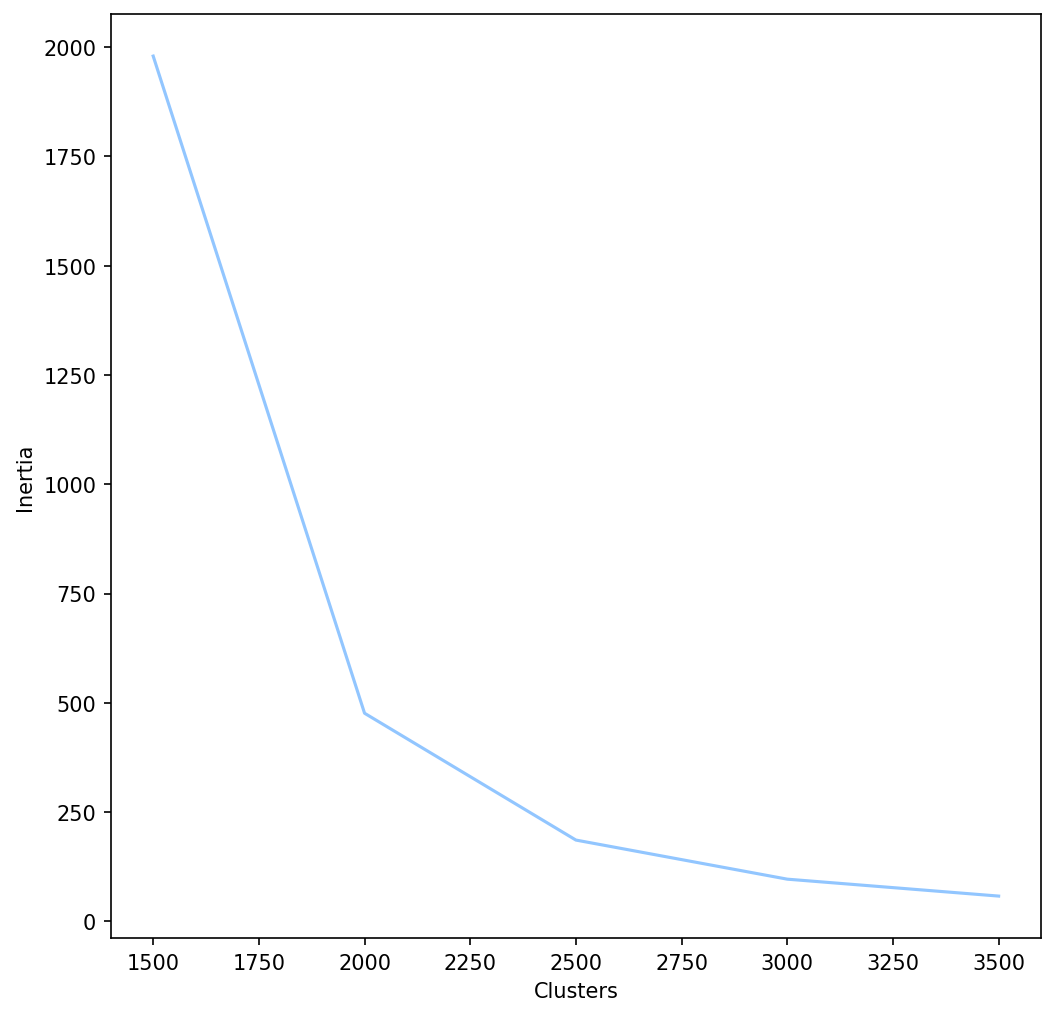

In [62]:
fig, ax = plt.subplots(figsize=(8,8))
sns.lineplot(data=res[(res['clusters'] > 1000) & (res['clusters'] < 4000)], x='clusters', y='inertia')
ax.set_xlabel('Clusters')
ax.set_ylabel('Inertia')
plt.show()

From the graph, it would seem that the elbow of our inertia graph is somewhere between `2000` and `2500`.

We can set our desired number of clusters to `2250`, to be safe.

In [63]:
n_clusters = 2250

In [64]:
scaler = StandardScaler()
model = KMeans(n_clusters=n_clusters)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=n_clusters, random_state=42))
])

pipeline.fit(df_d)
fitted_kmeans = pipeline.named_steps["kmeans"]
inertia = fitted_kmeans.inertia_

In [65]:
print(inertia)

280.58201707710947


This is our chosen ideal model.

Let's try two things. First, we'll visualize the results. Secondly, we'll make a proposed project and see about the best fit for a cluster. We'll take a look at other projects in that clusters to compare.

In [66]:
# Set the predicted cluster label for each row
df_d['cluster'] = fitted_kmeans.labels_

Let's see how the centroids plot before we overlay the data points.

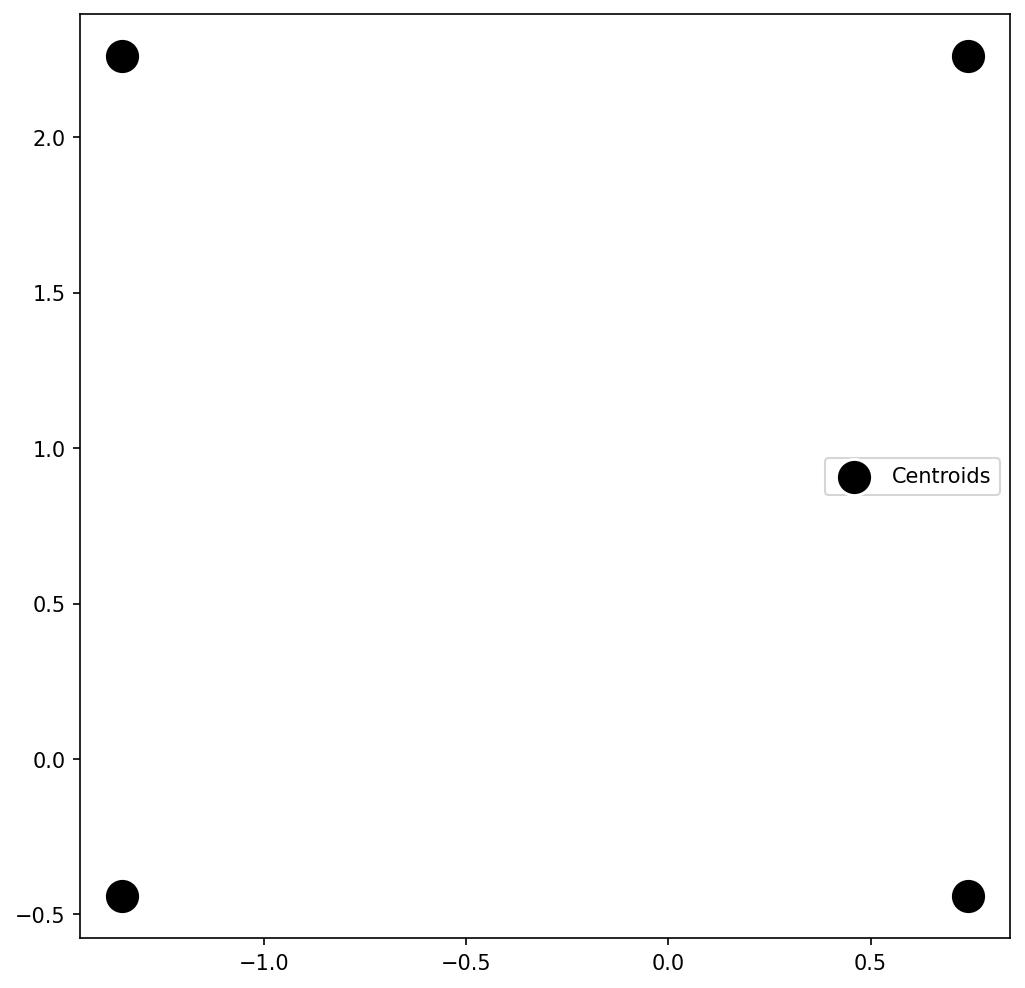

In [67]:
fig, ax = plt.subplots(figsize=(8,8))
sns.scatterplot(x=fitted_kmeans.cluster_centers_[:, 0], y=fitted_kmeans.cluster_centers_[:, 1],
                s=300, c='black', marker='o', label='Centroids')
plt.show()

The centroids all appear to be in one of the four corners of the plot. Let's check the individual values to see if there's variance.

In [68]:
pd.DataFrame(np.round(fitted_kmeans.cluster_centers_[:, 0], 2)).value_counts()

0    
 0.74    1507
-1.35     743
Name: count, dtype: int64

In [69]:
pd.DataFrame(np.round(fitted_kmeans.cluster_centers_[:, 1], decimals=2)).value_counts()

0    
-0.44    1319
 2.26     931
Name: count, dtype: int64

When rounding to `2` decimal places, we're left with just four identical cluster centers.

This suggests that our initial KMeans setup needs improvement.

Let's see how many unique centroids we get if we do just a few clusters.

In [70]:
n_clusters = 25

scaler = StandardScaler()
model = KMeans(n_clusters=n_clusters)
pipeline_2 = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=n_clusters, random_state=42))
])

pipeline_2.fit(df_d)
fitted_kmeans_2 = pipeline_2.named_steps["kmeans"]
inertia = fitted_kmeans_2.inertia_

In [71]:
print(inertia)

2084115.6861988148


In [72]:
# Set the predicted cluster label for each row
df_d['cluster_2'] = fitted_kmeans_2.labels_

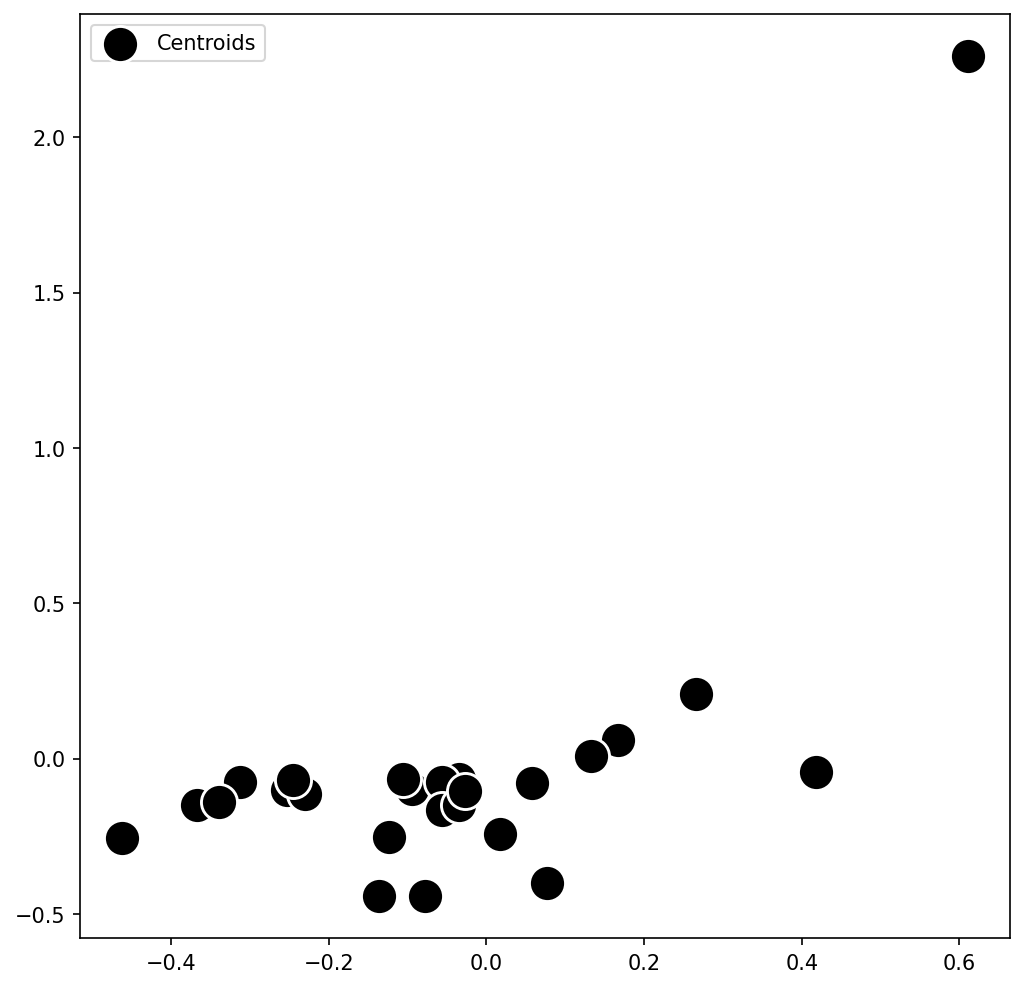

In [73]:
fig, ax = plt.subplots(figsize=(8,8))
sns.scatterplot(x=fitted_kmeans_2.cluster_centers_[:, 0], y=fitted_kmeans_2.cluster_centers_[:, 1],
                s=300, c='black', marker='o', label='Centroids')
plt.show()

In [74]:
len(fitted_kmeans_2.cluster_centers_[:, 0])

25

As we see here, now we are getting variance. We set k to `25` and we see a total of `25` unique centroids, which fits our number of clusters.

Let's try using `init=kmeans++` to see if that helps spread out our cluster centers on the `2250` cluster version. 

In [75]:
n_clusters = 2250

In [76]:
scaler = StandardScaler()
model = KMeans(n_clusters=n_clusters)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=n_clusters, init='k-means++', random_state=42))
])

pipeline.fit(df_d)
fitted_kmeans = pipeline.named_steps["kmeans"]
inertia = fitted_kmeans.inertia_

In [77]:
print(inertia)

312.5716472096596


Our inertia has gone up from `280.582` to `307.678`.

First, let's check and see if our clusters are unique now.

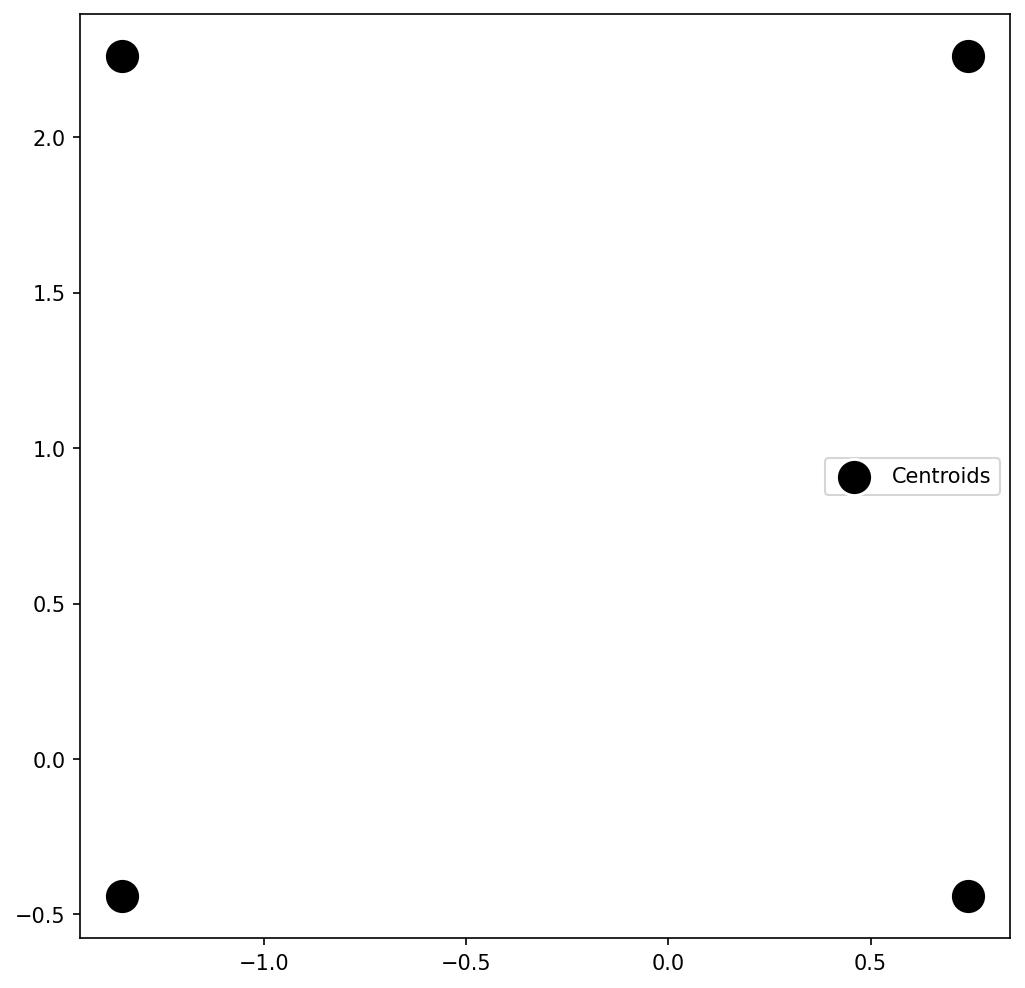

In [78]:
fig, ax = plt.subplots(figsize=(8,8))
sns.scatterplot(x=fitted_kmeans.cluster_centers_[:, 0], y=fitted_kmeans.cluster_centers_[:, 1],
                s=300, c='black', marker='o', label='Centroids')
plt.show()

Let's create an algorithm that shows us how the centroids converge as we increase the number of clusters.

In [79]:
run_centroids = False

In [80]:
results_centroids = np.array([])

In [81]:
possible_k = list(range(25, 2250, 25))

In [82]:
def calculate_unique_centroids(df):
    df['grouped'] = list(zip(df['x'], df['y']))
    num_unique_centroids = df['grouped'].nunique()
    return num_unique_centroids

In [83]:
if run_centroids:
    for i in possible_k:
        start_time = time.perf_counter()
        print(f"Starting cluster of value: {i}")
        scaler = StandardScaler()
        model = KMeans(n_clusters=i)
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('kmeans', KMeans(n_clusters=i, init='k-means++', random_state=42))
        ])
    
        pipeline.fit(df_d)
        fitted_kmeans = pipeline.named_steps["kmeans"]
        inertia = np.round(fitted_kmeans.inertia_, decimals=2)
        
        temp_cent = pd.DataFrame({
            'x': np.round(fitted_kmeans.cluster_centers_[:, 0], 2),
            'y': np.round(fitted_kmeans.cluster_centers_[:, 1], 2)
        })

        num_unique_centroids = calculate_unique_centroids(temp_cent)
        
        print(f"number of unique centroids: {num_unique_centroids}")
        print(f"inertia: {inertia}")

        results_centroids = np.append(results_centroids, [i, num_unique_centroids, inertia], axis=0)
        end_time = time.perf_counter()
        elapsed_time = end_time - start_time
        print(f"Elapsed time: {elapsed_time:.4f} seconds\n")

In [84]:
res_centroids = pd.DataFrame()
if run_centroids:
    a = results_centroids[::3]
    b = results_centroids[1::3]
    c = results_centroids[2::3]
    res_centroids = pd.DataFrame(
        {'clusters': a,
         'num_unique_centroids': b,
        'inertia': c}
    )

In [85]:
if run_centroids:
    print(res_centroids.to_dict(orient='list'))

In [86]:
if (run_centroids == False):
    res_centroids = pd.DataFrame(
        {
        'clusters': [25.0, 50.0, 75.0, 100.0, 125.0, 150.0, 175.0, 200.0, 225.0, 250.0, 275.0, 300.0, 325.0, 350.0, 375.0, 400.0, 425.0, 450.0, 475.0, 500.0, 525.0, 550.0, 575.0, 600.0, 625.0, 650.0, 675.0, 700.0, 725.0, 750.0, 775.0, 800.0, 825.0, 850.0, 875.0, 900.0, 925.0, 950.0, 975.0, 1000.0, 1025.0, 1050.0, 1075.0, 1100.0, 1125.0, 1150.0, 1175.0, 1200.0, 1225.0, 1250.0, 1275.0, 1300.0, 1325.0, 1350.0, 1375.0, 1400.0, 1425.0, 1450.0, 1475.0, 1500.0, 1525.0, 1550.0, 1575.0, 1600.0, 1625.0, 1650.0, 1675.0, 1700.0, 1725.0, 1750.0, 1775.0, 1800.0, 1825.0, 1850.0, 1875.0, 1900.0, 1925.0, 1950.0, 1975.0, 2000.0, 2025.0, 2050.0, 2075.0, 2100.0, 2125.0, 2150.0, 2175.0, 2200.0, 2225.0],
        'num_unique_centroids': [25.0, 47.0, 71.0, 94.0, 109.0, 125.0, 142.0, 160.0, 178.0, 195.0, 214.0, 229.0, 242.0, 255.0, 260.0, 273.0, 284.0, 295.0, 308.0, 312.0, 320.0, 323.0, 323.0, 330.0, 336.0, 333.0, 331.0, 334.0, 328.0, 318.0, 314.0, 309.0, 307.0, 300.0, 298.0, 282.0, 271.0, 266.0, 264.0, 255.0, 249.0, 243.0, 238.0, 221.0, 217.0, 204.0, 199.0, 191.0, 182.0, 179.0, 168.0, 160.0, 155.0, 145.0, 140.0, 136.0, 129.0, 121.0, 116.0, 111.0, 108.0, 101.0, 96.0, 92.0, 88.0, 82.0, 77.0, 74.0, 70.0, 66.0, 58.0, 49.0, 43.0, 39.0, 37.0, 32.0, 29.0, 25.0, 25.0, 23.0, 21.0, 21.0, 13.0, 9.0, 8.0, 4.0, 4.0, 4.0, 4.0],
        'inertia': [2152271.28, 798076.77, 557353.41, 419805.69, 347219.99, 294568.78, 250151.91, 216459.82, 188927.32, 166753.77, 148752.6, 131084.42, 118665.63, 106270.1, 97169.87, 88540.97, 80139.47, 73287.81, 67881.03, 62780.55, 57469.13, 53335.1, 49048.4, 45352.87, 42335.34, 39248.9, 36805.75, 34215.19, 32123.85, 29873.73, 27751.28, 25968.35, 24213.06, 22624.59, 21125.86, 19785.02, 18622.63, 17525.54, 16551.2, 15434.73, 14492.76, 13629.16, 12862.8, 12133.58, 11451.19, 10849.07, 10171.61, 9507.39, 8963.92, 8452.87, 7939.12, 7412.48, 6939.15, 6494.03, 6061.26, 5713.86, 5364.35, 5034.48, 4712.93, 4427.73, 4113.82, 3836.63, 3582.2, 3351.39, 3117.07, 2912.0, 2717.71, 2522.93, 2341.29, 2190.04, 2034.64, 1897.79, 1743.62, 1601.69, 1462.05, 1343.89, 1223.81, 1109.95, 1015.31, 926.07, 830.51, 749.4, 664.91, 586.81, 514.8, 450.8, 403.76, 362.59, 328.9]
        }
    )

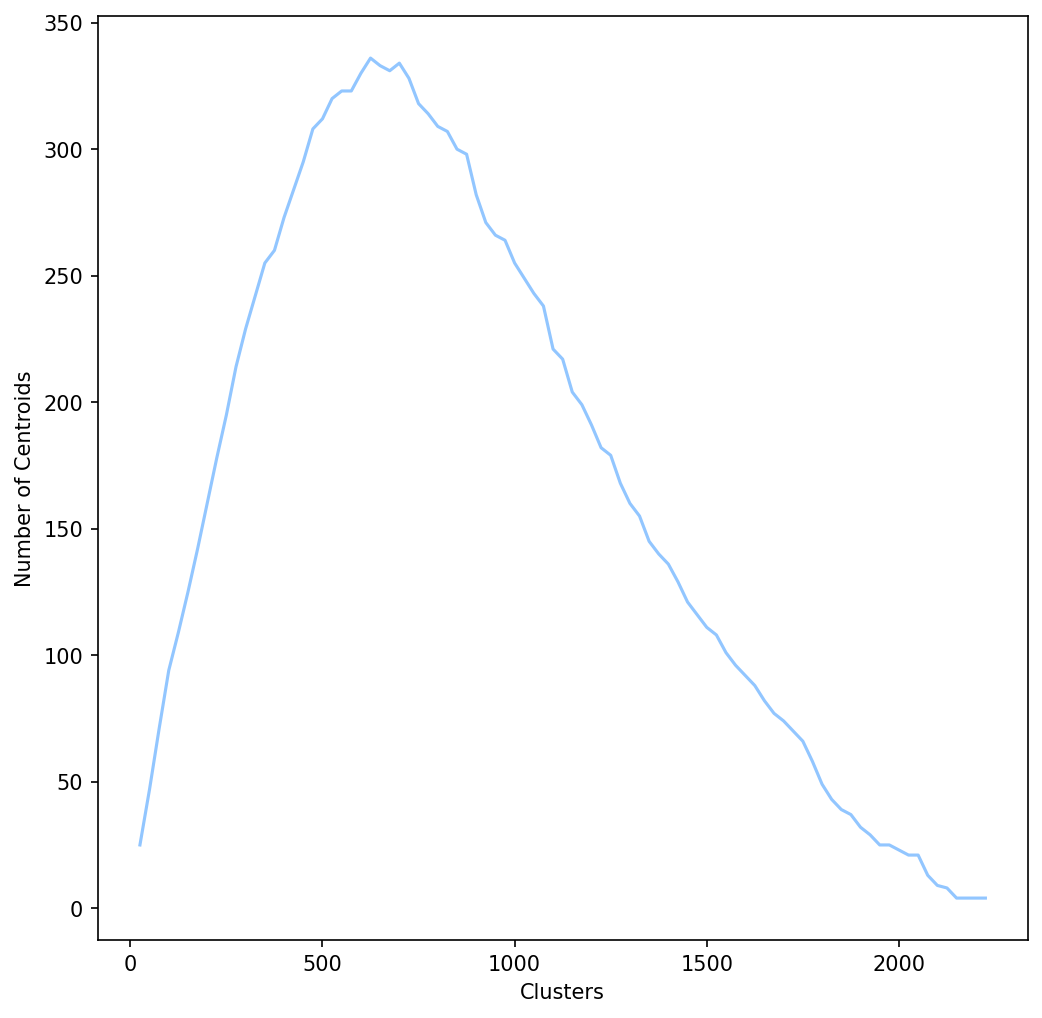

In [87]:
fig, ax = plt.subplots(figsize=(8,8))
#sns.lineplot(data=res_centroids[(res_centroids['clusters'] > 1000) & (res_centroids['clusters'] < 4000)], x='clusters', y='num_centroids')
sns.lineplot(data=res_centroids, x='clusters', y='num_unique_centroids')
ax.set_xlabel('Clusters')
ax.set_ylabel('Number of Centroids')
plt.show()

As we see here, the number of cluster centroids maxes out with an initial value of `625` clusters, which collapses to `336` clusters.

After that, the clusters collapse into smaller groups until, at our elbow joint of `2250` initial clusters, we end up with only `4` clusters remaining.

To make this study useful, therefore, we need to reduce the initial number of clusters to their maximum final output.

In [132]:
df_d = df_d.drop(columns=['cluster', 'cluster_2'])

KeyError: "['cluster_2'] not found in axis"

In [174]:
df_d = df_d.drop(columns=['cluster'])

KeyError: "['cluster'] not found in axis"

In [175]:
n_clusters = 625

In [176]:
scaler = StandardScaler()
model = KMeans(n_clusters=n_clusters)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=n_clusters, init='k-means++', random_state=42))
])

pipeline.fit(df_d)
fitted_kmeans = pipeline.named_steps["kmeans"]
fitted_scaler = pipeline.named_steps['scaler']

In [177]:
print(len(fitted_kmeans.cluster_centers_[:, 0]))

625


In [178]:
#centroids = pd.DataFrame(
#    kmeans.cluster_centers_, columns=["x", "y"]
#)


In [179]:
centroids_df = pd.DataFrame(fitted_scaler.inverse_transform(fitted_kmeans.cluster_centers_), columns=df_d.columns)

In [180]:
df_d['cluster'] = fitted_kmeans.labels_

In [181]:
df_d.head()

,state,staff_pick,backers_count,creator.backing_action_count,converted_goal_amount,c_AT,c_AU,c_BE,c_CA,c_CH,c_DE,c_DK,c_ES,c_FR,c_GB,c_GR,c_HK,c_IE,c_IT,c_JP,c_LU,c_MX,c_NL,c_NO,c_NZ,c_PL,c_SE,c_SG,c_SI,c_US,c_AUD,c_CAD,c_CHF,c_DKK,c_EUR,c_GBP,c_HKD,c_JPY,c_MXN,c_NOK,c_NZD,c_PLN,c_SEK,c_SGD,c_USD,c_1.0,c_3.0,c_6.0,c_7.0,c_9.0,c_10.0,c_11.0,c_12.0,c_13.0,c_14.0,c_15.0,c_16.0,c_17.0,c_18.0,c_26.0,cluster
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1703332404,0,0,3,0,53170.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,39
1704943227,0,0,0,0,10302.7250,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,18
150178599,0,0,2,0,2578.8137,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,145
699875365,0,0,3,0,150537.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,39
739499553,0,0,0,0,3900.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,39


In [182]:
list(df_d.columns[0:5])

['state',
 'staff_pick',
 'backers_count',
 'creator.backing_action_count',
 'converted_goal_amount']

In [183]:
centroids_df.sort_values(by='converted_goal_amount', ascending=False).head()

,state,staff_pick,backers_count,creator.backing_action_count,converted_goal_amount,c_AT,c_AU,c_BE,c_CA,c_CH,c_DE,c_DK,c_ES,c_FR,c_GB,c_GR,c_HK,c_IE,c_IT,c_JP,c_LU,c_MX,c_NL,c_NO,c_NZ,c_PL,c_SE,c_SG,c_SI,c_US,c_AUD,c_CAD,c_CHF,c_DKK,c_EUR,c_GBP,c_HKD,c_JPY,c_MXN,c_NOK,c_NZD,c_PLN,c_SEK,c_SGD,c_USD,c_1.0,c_3.0,c_6.0,c_7.0,c_9.0,c_10.0,c_11.0,c_12.0,c_13.0,c_14.0,c_15.0,c_16.0,c_17.0,c_18.0,c_26.0
42,0.0,0.0,2.0,0.0,1.019834e+08,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000e+00,0.0,0.5,8.673617e-19,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.500000,0.0,0.000000e+00,0.000000e+00,0.0,0.500000,0.0,0.000000e+00,8.673617e-19,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.500000,0.000000,0.0,0.0,-1.734723e-18,0.000000e+00,0.000000e+00,0.500000,0.000000e+00,0.000000e+00,0.000000e+00,6.938894e-18,5.000000e-01,0.000000e+00,0.0,0.000000e+00
302,0.0,0.0,1.0,0.0,5.051929e+07,0.0,0.0,0.0,0.0,1.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000e+00,0.0,0.0,8.673617e-19,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000e+00,1.000000e+00,0.0,0.000000,0.0,0.000000e+00,8.673617e-19,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.0,0.0,-1.734723e-18,0.000000e+00,0.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,6.938894e-18,-1.387779e-17,0.000000e+00,0.0,0.000000e+00
43,0.0,0.0,1.2,0.0,5.040000e+07,0.0,0.0,0.0,0.0,0.0,-3.469447e-18,-8.673617e-19,-1.734723e-18,0.000000,0.0,-4.336809e-19,-1.734723e-18,0.0,0.0,-8.673617e-19,0.000000e+00,0.0,-8.673617e-19,0.0,0.0,0.0,-8.673617e-19,-4.336809e-19,-1.084202e-19,1.000000,0.0,-6.938894e-18,0.000000e+00,0.0,0.000000,0.0,-1.734723e-18,-8.673617e-19,0.0,0.0,0.0,-4.336809e-19,-8.673617e-19,-4.336809e-19,1.000000,0.200000,0.0,0.0,-1.734723e-18,0.000000e+00,0.000000e+00,0.800000,0.000000e+00,-6.938894e-18,-2.775558e-17,6.938894e-18,-1.387779e-17,-6.938894e-18,0.0,-1.387779e-17
411,0.0,0.0,25.0,0.0,3.035208e+07,0.0,0.0,0.0,0.0,0.0,3.469447e-18,0.000000e+00,1.734723e-18,0.333333,0.0,0.000000e+00,1.734723e-18,0.0,0.0,1.734723e-18,1.084202e-19,0.0,8.673617e-19,0.0,0.0,0.0,8.673617e-19,0.000000e+00,0.000000e+00,0.666667,0.0,0.000000e+00,4.336809e-19,0.0,0.333333,0.0,1.734723e-18,1.734723e-18,0.0,0.0,0.0,4.336809e-19,8.673617e-19,0.000000e+00,0.666667,0.333333,0.0,0.0,-1.734723e-18,4.336809e-19,1.387779e-17,0.666667,1.387779e-17,0.000000e+00,0.000000e+00,2.081668e-17,-1.387779e-17,0.000000e+00,0.0,0.000000e+00
571,0.0,0.0,2.0,0.0,2.359553e+07,0.0,1.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000e+00,0.0,0.0,8.673617e-19,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.0,0.000000e+00,0.000000e+00,0.0,0.000000,0.0,0.000000e+00,8.673617e-19,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.0,0.0,-1.734723e-18,0.000000e+00,0.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,6.938894e-18,-1.387779e-17,0.000000e+00,0.0,0.000000e+00


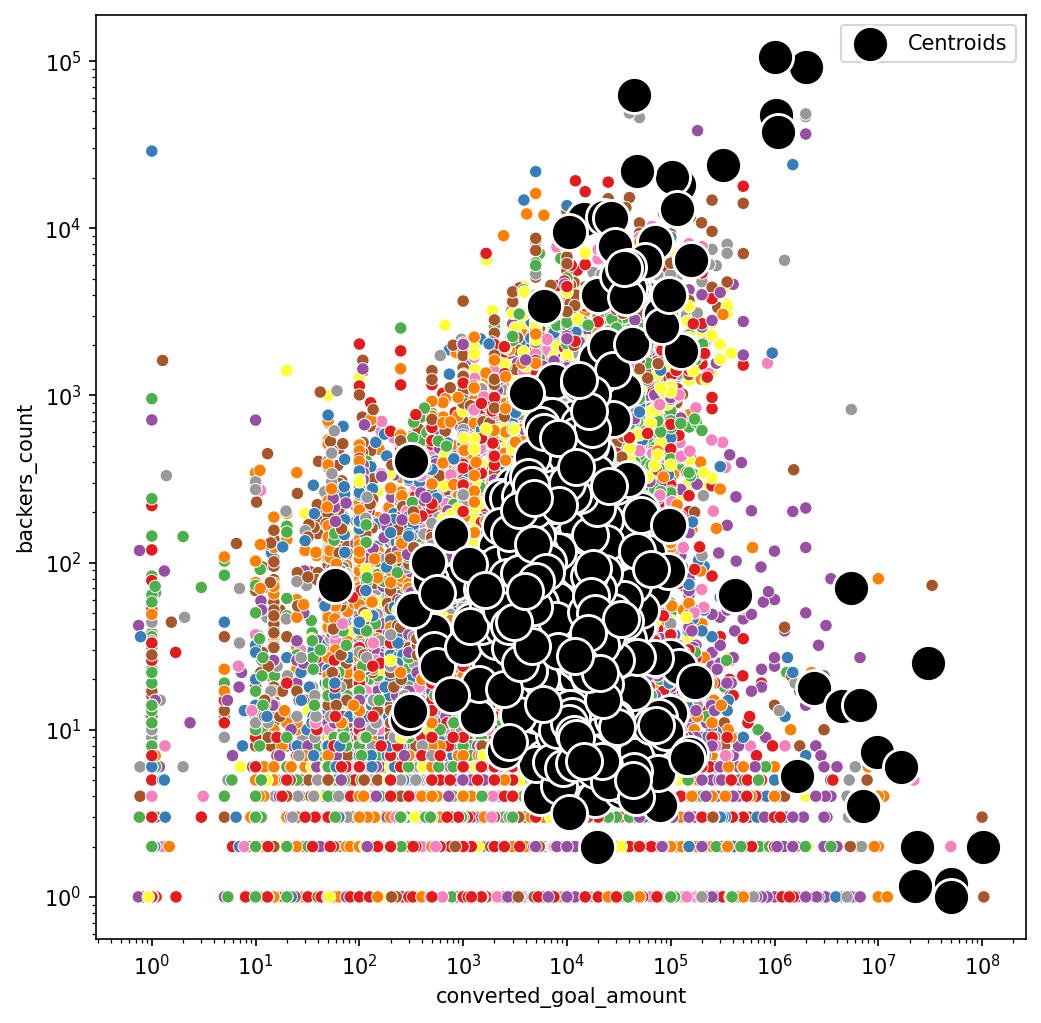

In [187]:
fig, ax = plt.subplots(figsize=(8,8))
sns.scatterplot(x=df_d['converted_goal_amount'], y=df_d['backers_count'], hue=df_d['cluster'], palette='Set1', legend=False)
sns.scatterplot(x=centroids_df['converted_goal_amount'], y=centroids_df['backers_count'],
                s=300, c='black', marker='o', label='Centroids')
ax.set_xscale('log')
ax.set_yscale('log')
plt.show()

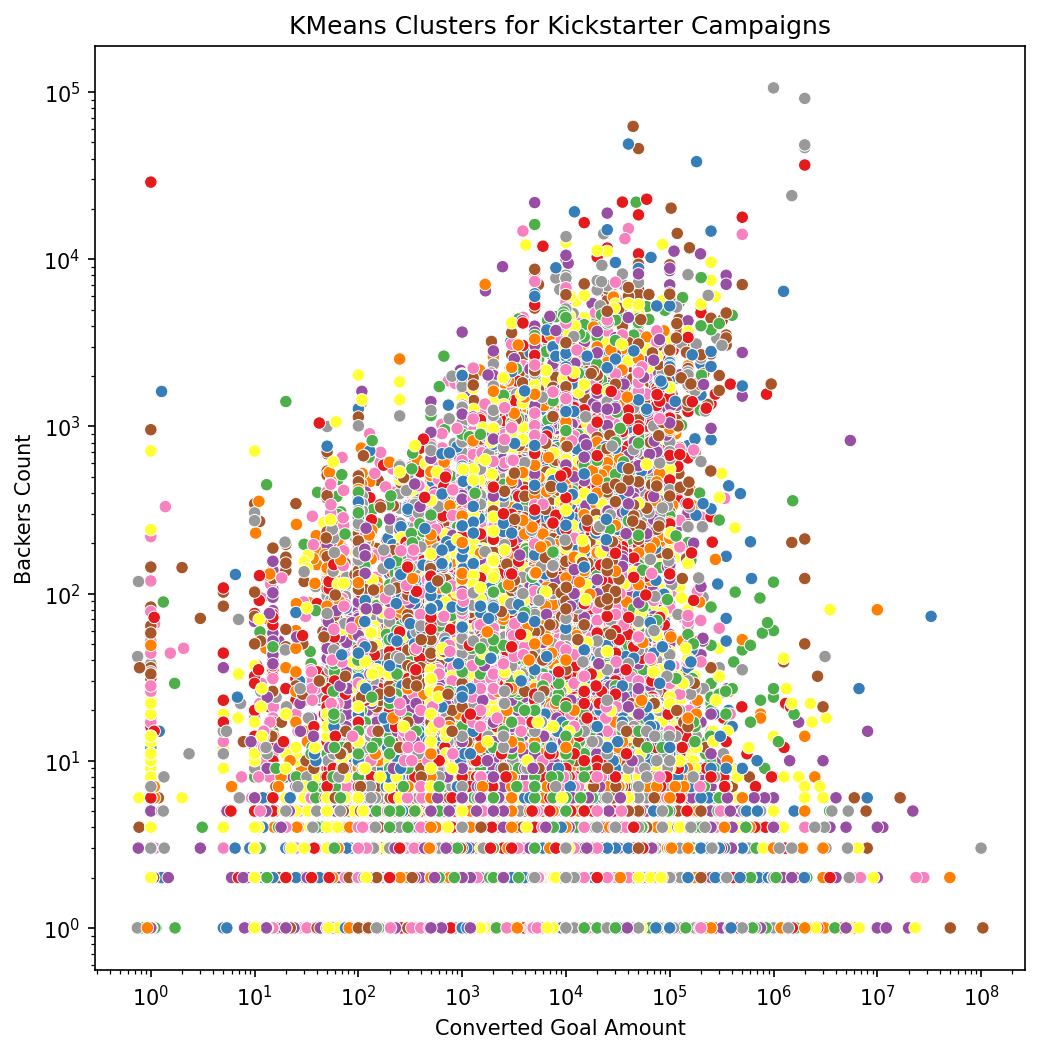

In [186]:
fig, ax = plt.subplots(figsize=(8,8))
sns.scatterplot(x=df_d['converted_goal_amount'], y=df_d['backers_count'], hue=df_d['cluster'], palette='Set1', legend=False)
# plt.scatter(fitted_kmeans.cluster_centers_[:, 0], fitted_kmeans.cluster_centers_[:, 1], 
#            s=300, c='black', marker='o', label='Centroids')
ax.set_xlabel('Converted Goal Amount')
ax.set_ylabel('Backers Count')
ax.set_title('KMeans Clusters for Kickstarter Campaigns')
ax.set_xscale('log')
ax.set_yscale('log')
plt.show()

In [187]:
print(len(df_d[df_d['cluster'] == 1001]))

11


In [189]:
df_d[df_d['cluster'] == 1002].head()

,staff_pick,backers_count,creator.backing_action_count,converted_goal_amount,state_adj,c_AT,c_AU,c_BE,c_CA,c_CH,c_DE,c_DK,c_ES,c_FR,c_GB,c_GR,c_HK,c_IE,c_IT,c_JP,c_LU,c_MX,c_NL,c_NO,c_NZ,c_PL,c_SE,c_SG,c_SI,c_US,c_AUD,c_CAD,c_CHF,c_DKK,c_EUR,c_GBP,c_HKD,c_JPY,c_MXN,c_NOK,c_NZD,c_PLN,c_SEK,c_SGD,c_USD,c_1.0,c_3.0,c_6.0,c_7.0,c_9.0,c_10.0,c_11.0,c_12.0,c_13.0,c_14.0,c_15.0,c_16.0,c_17.0,c_18.0,c_26.0,cluster,log_goal,log_backers
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1318874538,False,1,0,3873.557688,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,1002,3.588222,0.301030
150799549,False,2,0,5318.300250,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,1002,3.725855,0.477121


In [190]:
df_d[df_d['c_AT']].head()

,staff_pick,backers_count,creator.backing_action_count,converted_goal_amount,state_adj,c_AT,c_AU,c_BE,c_CA,c_CH,c_DE,c_DK,c_ES,c_FR,c_GB,c_GR,c_HK,c_IE,c_IT,c_JP,c_LU,c_MX,c_NL,c_NO,c_NZ,c_PL,c_SE,c_SG,c_SI,c_US,c_AUD,c_CAD,c_CHF,c_DKK,c_EUR,c_GBP,c_HKD,c_JPY,c_MXN,c_NOK,c_NZD,c_PLN,c_SEK,c_SGD,c_USD,c_1.0,c_3.0,c_6.0,c_7.0,c_9.0,c_10.0,c_11.0,c_12.0,c_13.0,c_14.0,c_15.0,c_16.0,c_17.0,c_18.0,c_26.0,cluster,log_goal,log_backers
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1111333600,False,3,0,21342.598800,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2346,4.329268,0.602060
1160958002,True,34,0,1110.626589,1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,1815,3.045959,1.544068
853949769,False,3,0,8154.435960,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2346,3.911447,0.602060
762606193,False,19,0,20299.507920,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2346,4.307507,1.301030
379671595,False,13,0,27842.744250,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,2346,4.444728,1.146128
